# Segmentação de Clientes - Mall Customer Segmentation

Este notebook tem como objetivo identificar perfis de consumo dos clientes de um shopping, a partir de dados de renda anual e comportamento de gasto (spending score).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Análise Exploratória (EDA)

Antes de aplicar qualquer modelo, é importante entender a distribuição das variáveis disponíveis: idade, renda anual e spending score (índice de propensão a gastar atribuído pelo shopping).

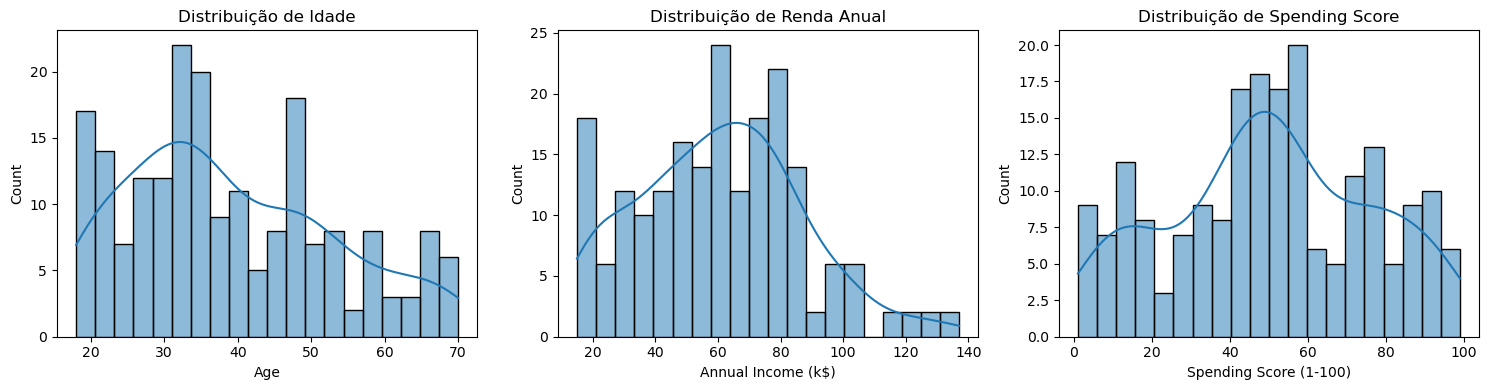

In [3]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribuição de Idade')

plt.subplot(1, 3, 2)
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title('Distribuição de Renda Anual')

plt.subplot(1, 3, 3)
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title('Distribuição de Spending Score')

plt.tight_layout()
plt.show()

In [4]:
sexos = df['Gender'].value_counts()

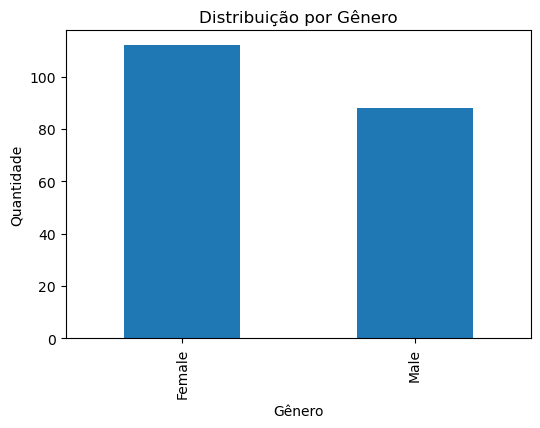

In [5]:
sexos.plot(kind='bar', figsize=(6, 4))
plt.title('Distribuição por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

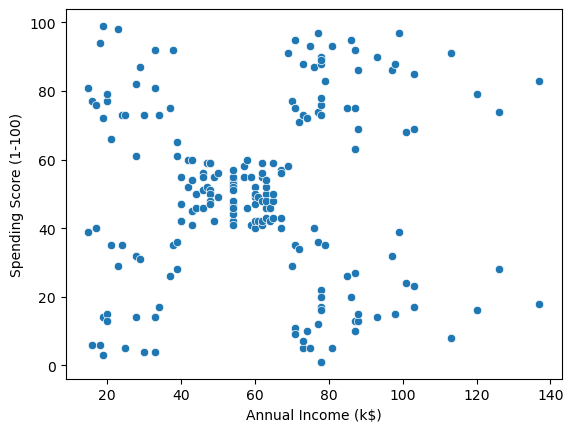

In [6]:
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)')

## Pré-processamento

Para permitir a visualização em 2D, o modelo será treinado usando apenas `Annual Income (k$)` e `Spending Score (1-100)`. Como o algoritmo de clusterização usa distância euclidiana, as variáveis são padronizadas com `StandardScaler` para que nenhuma domine o cálculo por estar em uma escala maior.

In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Escolha do Número Ideal de Clusters

Para segmentar os clientes, será usado o **K-Means**, um algoritmo de clusterização que agrupa os dados em K grupos com base na proximidade entre os pontos. Para definir o valor de K, foram usados três métodos complementares:
- **Método do Cotovelo (WCSS)**
- **Silhouette Score** para cada K testado
- **KneeLocator**, para identificar o cotovelo de forma automática/objetiva


c:\Users\eopal\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\eopal\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\eopal\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarn

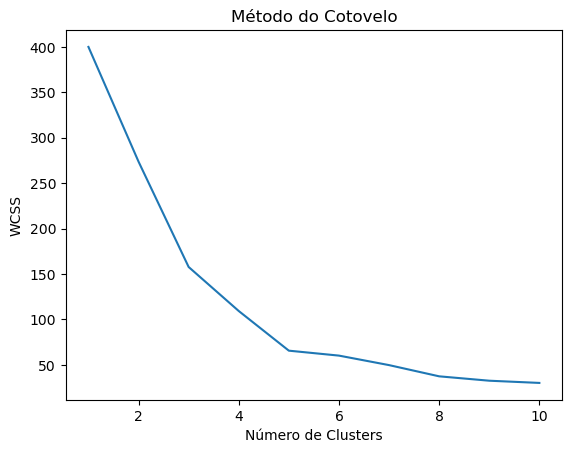

In [9]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.title('Método do Cotovelo')
plt.show()

c:\Users\eopal\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\eopal\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\eopal\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\eopal\AppData\Local\spyder-6

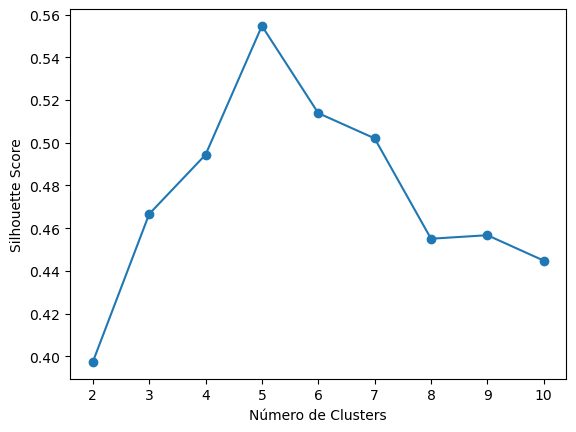

In [10]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [11]:
melhor_k = range(2, 11)[scores.index(max(scores))]
print(melhor_k)

5


In [12]:
from kneed import KneeLocator
kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
print(kl.elbow)

5


Os três modelos deram o mesmo resultado!

## Treinamento dos Modelos

Com K=5 definido, o K-Means é treinado com `n_init=20` (múltiplas inicializações, para reduzir a chance de convergir em um mínimo local ruim). Para efeito de comparação, também será treinado um **Hierarchical Clustering (Agglomerative)**, um algoritmo que constrói os grupos de forma hierárquica ao invés de otimizar centroides, sobre os mesmos dados padronizados.

In [13]:
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=20, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

c:\Users\eopal\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


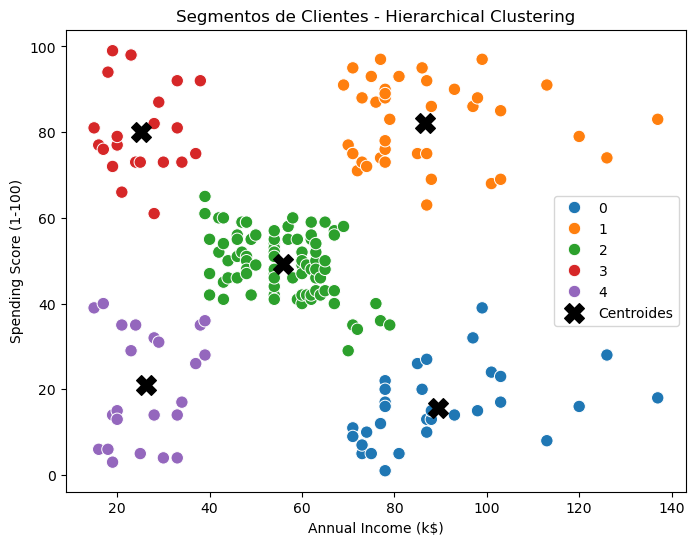

In [15]:
df_hc = df.copy()

hc = AgglomerativeClustering(n_clusters=5)
df_hc['Cluster'] = hc.fit_predict(X_scaled)

centroides_hc = df_hc.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_hc, x='Annual Income (k$)', y='Spending Score (1-100)',
                 hue='Cluster', palette='tab10', s=80)
plt.scatter(centroides_hc['Annual Income (k$)'], centroides_hc['Spending Score (1-100)'],
            s=200, c='black', marker='X', label='Centroides')
plt.title('Segmentos de Clientes - Hierarchical Clustering')
plt.legend()
plt.show()

In [17]:
df['Cluster'] = y_kmeans


In [36]:
y_hc = hc.fit_predict(X_scaled)
df_hc['Cluster'] = y_hc

In [19]:
df['Cluster'].value_counts()
df['Cluster'].value_counts().mean()

np.float64(40.0)

## Interpretação dos Clusters

A tabela abaixo mostra a média de idade, renda e spending score de cada cluster, usada para nomear os segmentos de acordo com o perfil de consumo. Como os índices de cluster são atribuídos arbitrariamente por cada algoritmo (não seguem uma ordem fixa de significado), os dicionários de nomeação foram construídos separadamente para o K-Means e para o Hierarchical, a partir das médias reais de cada um.

In [20]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [21]:
df_hc.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,41.000000,89.406250,15.593750
1,32.692308,86.538462,82.128205
2,42.482353,55.811765,49.129412
3,25.333333,25.095238,80.047619
4,45.217391,26.304348,20.913043


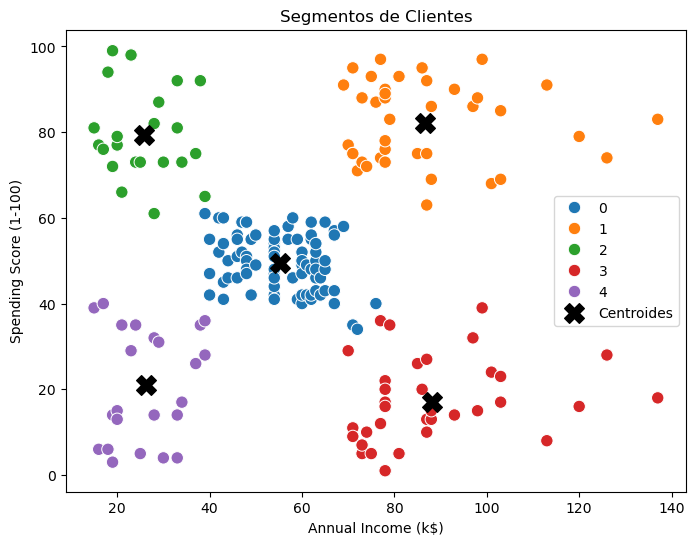

In [22]:
centroides_originais = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                 hue='Cluster', palette='tab10', s=80)
plt.scatter(centroides_originais[:, 0], centroides_originais[:, 1],
            s=200, c='black', marker='X', label='Centroides')
plt.title('Segmentos de Clientes')
plt.legend()
plt.show()

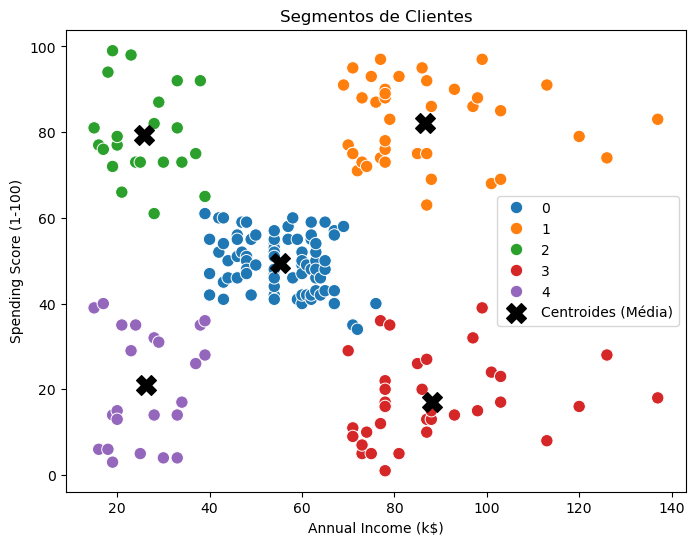

In [35]:
colunas_features = ['Annual Income (k$)', 'Spending Score (1-100)']
centroides_originais = df.groupby('Cluster')[colunas_features].mean().values

# 2. Gera o gráfico
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)',
    hue='Cluster', 
    palette='tab10', 
    s=80
)

# Plota os centroides calculados
plt.scatter(
    centroides_originais[:, 0], 
    centroides_originais[:, 1],
    s=200, 
    c='black', 
    marker='X', 
    label='Centroides (Média)'
)

plt.title('Segmentos de Clientes')
plt.legend()
plt.show()

In [29]:
nomes_clusters = {
    0: 'Renda média, gasto médio (padrão)',
    1: 'Renda alta, gasto alto (clientes-alvo)',
    2: 'Renda baixa, gasto alto (impulsivos)',
    3: 'Renda alta, gasto baixo (poupadores)',
    4: 'Renda baixa, gasto baixo (cautelosos)'
}

nomes_clusters_hc = {
    0: 'Renda alta, gasto baixo (poupadores)',
    1: 'Renda alta, gasto alto (clientes-alvo)',
    2: 'Renda média, gasto médio (padrão)',
    3: 'Renda baixa, gasto alto (impulsivos)',
    4: 'Renda baixa, gasto baixo (cautelosos)'
}


df['Segmento'] = df['Cluster'].map(nomes_clusters)
df_hc['Segmento'] = df_hc['Cluster'].map(nomes_clusters_hc)

In [30]:
df_hc

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segmento
0,1,Male,19,15,39,4,"Renda baixa, gasto baixo (cautelosos)"
1,2,Male,21,15,81,3,"Renda baixa, gasto alto (impulsivos)"
2,3,Female,20,16,6,4,"Renda baixa, gasto baixo (cautelosos)"
3,4,Female,23,16,77,3,"Renda baixa, gasto alto (impulsivos)"
4,5,Female,31,17,40,4,"Renda baixa, gasto baixo (cautelosos)"
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,"Renda alta, gasto alto (clientes-alvo)"
196,197,Female,45,126,28,0,"Renda alta, gasto baixo (poupadores)"
197,198,Male,32,126,74,1,"Renda alta, gasto alto (clientes-alvo)"
198,199,Male,32,137,18,0,"Renda alta, gasto baixo (poupadores)"


In [31]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segmento
0,1,Male,19,15,39,4,"Renda baixa, gasto baixo (cautelosos)"
1,2,Male,21,15,81,2,"Renda baixa, gasto alto (impulsivos)"
2,3,Female,20,16,6,4,"Renda baixa, gasto baixo (cautelosos)"
3,4,Female,23,16,77,2,"Renda baixa, gasto alto (impulsivos)"
4,5,Female,31,17,40,4,"Renda baixa, gasto baixo (cautelosos)"
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,"Renda alta, gasto alto (clientes-alvo)"
196,197,Female,45,126,28,3,"Renda alta, gasto baixo (poupadores)"
197,198,Male,32,126,74,1,"Renda alta, gasto alto (clientes-alvo)"
198,199,Male,32,137,18,3,"Renda alta, gasto baixo (poupadores)"


## O que os Dados Revelam sobre os Clientes

Além da separação estatística, os clusters trazem informações úteis para decisões de negócio, considerando idade, renda e comportamento de gasto:

- **Clientes-alvo (renda alta, gasto alto)**: o grupo mais jovem entre os de renda alta (em torno de 33 anos), com alto poder de compra e alta propensão a gastar. É o segmento mais valioso para o shopping e o público prioritário para campanhas de fidelização e lançamentos de produtos premium.

- **Poupadores (renda alta, gasto baixo)**: têm poder de compra semelhante ao grupo anterior, mas gastam pouco no shopping. Representam uma oportunidade: entender por que essa renda não se converte em consumo pode direcionar ações específicas (promoções direcionadas, novos serviços) para capturar esse potencial não realizado.

- **Impulsivos (renda baixa, gasto alto)**: o grupo mais jovem de todos (em torno de 25 anos), com renda baixa mas gasto desproporcionalmente alto. Pode indicar sensibilidade a tendências, moda ou lançamentos — vale investigar quais categorias de produto atraem esse público, já que ele gasta acima do que a renda sugeriria.

- **Cautelosos (renda baixa, gasto baixo)**: o grupo de clientes mais velhos (em torno de 45 anos) com menor renda e menor gasto. Tendem a ser mais criteriosos nas compras; promoções agressivas de preço podem ser mais eficazes aqui do que estratégias de exclusividade.

- **Padrão (renda média, gasto médio)**: o maior grupo em volume e o mais "equilibrado" nas três variáveis, representando o perfil médio do shopping. Estratégias generalistas de marketing tendem a funcionar bem para esse segmento.

De forma geral, o gasto não segue diretamente a renda: clientes de renda alta se dividem entre alto e baixo gasto, assim como clientes de renda baixa. Isso sugere que fatores comportamentais (não capturados neste dataset, como idade, estilo de vida ou sensibilidade a promoções) pesam tanto quanto o poder de compra na decisão de consumo — reforçando o valor de segmentar clientes além de simples faixas de renda.

In [32]:
from sklearn.metrics import silhouette_score
print(silhouette_score(X_scaled, y_kmeans))

0.5546571631111091


In [33]:
from sklearn.metrics import silhouette_score
print(silhouette_score(X_scaled, y_hc))

0.5538089226688662


## Conclusão

O K-Means e o Hierarchical Clustering apresentaram desempenho muito próximo neste dataset, com Silhouette Score de 0,5547 e 0,5538, respectivamente. A diferença é marginal, indicando que ambos os algoritmos conseguem capturar a mesma estrutura de 5 segmentos presente nos dados (renda x gasto).

Isso faz sentido dado o formato dos clusters observado no scatter plot: grupos relativamente esféricos e bem separados, uma condição em que tanto o K-Means quanto o Hierarchical Clustering costumam performar bem, resultando em segmentações praticamente equivalentes para este caso.